# Win probability with Machine Learning

## Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ML Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

## Importing data

In [4]:
INPUT_FILE = "master_ml_dataset.csv"

df = pd.read_csv(INPUT_FILE, low_memory=False, nrows=1000000)

print(f"Succesfully loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Succesfully loaded 1,000,000 rows and 704 columns.


In [5]:
# Target Y
y = df['target_win_t100']

# Features 
leakage_cols = ['matchId', 'timestamp', 'winningTeam', 'target_win_t100', 'type', 'team', 'actor_id']

# Filter
X = df.drop(columns=[col for col in leakage_cols if col in df.columns])

# Fill with 0-s
X = X.fillna(0)

# Only numericals
X = X.select_dtypes(include=[np.number])

print(f"Features: {X.shape[1]}")

Features: 685


In [6]:
# Unique match ids
unique_matches = df['matchId'].unique()
print(f"Összesen {len(unique_matches)} egyedi meccs van az 1 millió sorban.")

# Splitting
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)

train_df = df[df['matchId'].isin(train_matches)]
test_df = df[df['matchId'].isin(test_matches)]

# Features and label
y_train = train_df['target_win_t100']
y_test = test_df['target_win_t100']

# Filter
leakage_cols = ['matchId', 'timestamp', 'winningTeam', 'target_win_t100', 'type', 'team', 'actor_id']

X_train = train_df.drop(columns=[col for col in leakage_cols if col in train_df.columns]).fillna(0).select_dtypes(include=[np.number])
X_test = test_df.drop(columns=[col for col in leakage_cols if col in test_df.columns]).fillna(0).select_dtypes(include=[np.number])

print(f"Train: {X_train.shape[0]:,} lines ({len(train_matches)} matches)")
print(f"Test: {X_test.shape[0]:,} lines ({len(test_matches)} matches)")

Összesen 921 egyedi meccs van az 1 millió sorban.
Train: 802,173 lines (736 matches)
Test: 197,827 lines (185 matches)


In [7]:
# Model
log_model = LogisticRegression(solver='saga', max_iter=500, random_state=42)

# Train
log_model.fit(X_train, y_train)

# Prediction
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1] 

e:\BME\League-of-Legends-Esport-Analitika-2026\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
print("================ RESULTS ================\n")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = auc(*roc_curve(y_test, y_prob)[:2])

print(f"ACCURACY: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

================ RESULTS ================

ACCURACY: 71.39%
ROC-AUC Score: 0.7910

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70     90396
           1       0.76      0.69      0.72    107431

    accuracy                           0.71    197827
   macro avg       0.71      0.72      0.71    197827
weighted avg       0.72      0.71      0.71    197827



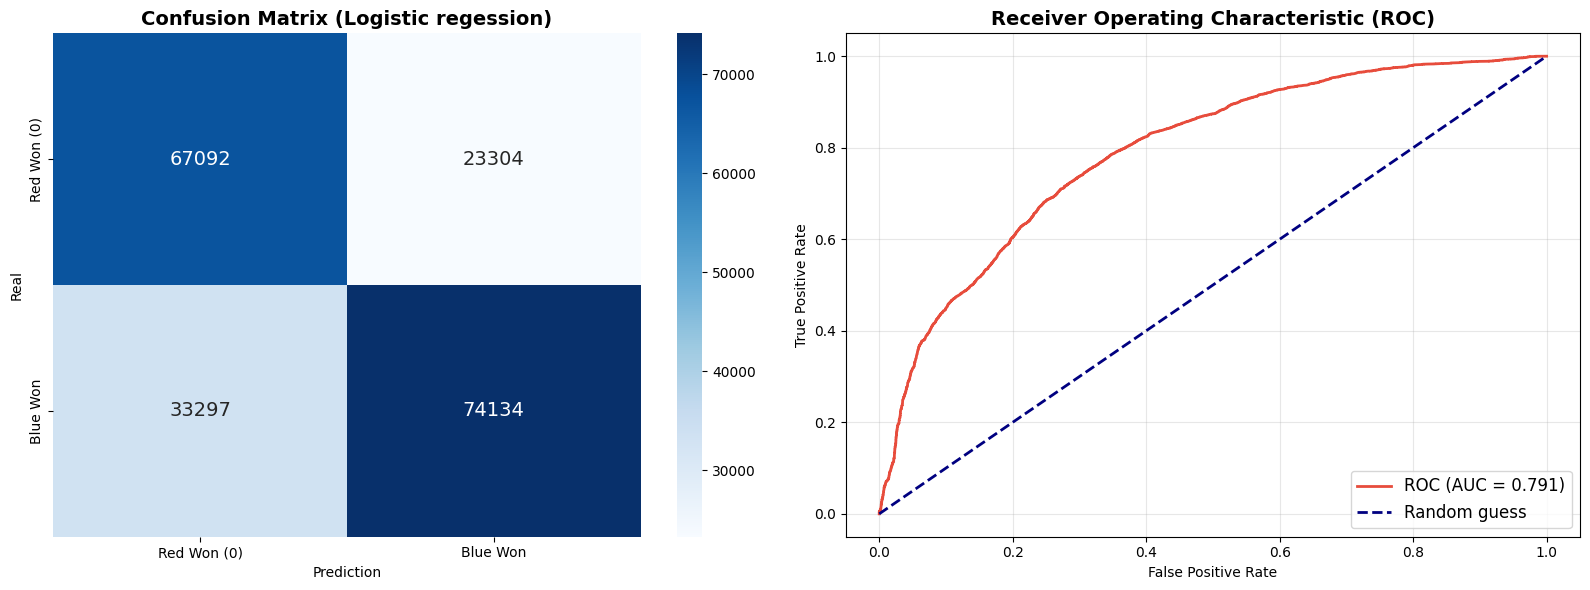


TOP 10 Most important features:
- dmg_magicDamageDoneToChampions_p4: 0.0001
- totalGold_diff                : 0.0001
- xp_p10                        : -0.0001
- stat_healthMax_t200           : -0.0001
- dmg_trueDamageTaken_p5        : 0.0001
- totalGold_t100                : 0.0001
- xp_p9                         : 0.0001
- totalGold_p9                  : -0.0001
- dmg_physicalDamageDoneToChampions_p4: -0.0001
- dmg_physicalDamageDoneToChampions_p1: 0.0001


In [19]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix (Logistic regession)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['Red Won (0)', 'Blue Won'])
axes[0].set_yticklabels(['Red Won (0)', 'Blue Won'])

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})
feature_importance['Abs_Coeff'] = feature_importance['Coefficient'].abs()
top_10_features = feature_importance.sort_values(by='Abs_Coeff', ascending=False).head(10)

print("\nTOP 10 Most important features:")
for index, row in top_10_features.iterrows():
    print(f"- {row['Feature']:<30}: {row['Coefficient']:.4f}")

## XGBoost

In [15]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [16]:
params = {
    'objective': 'binary:logistic',  
    'eval_metric': 'auc',            
    'max_depth': 6,                  
    'learning_rate': 0.1,            
    'subsample': 0.8,                
    'colsample_bytree': 0.8,         
    'tree_method': 'hist',          
    'n_jobs': -1,                    # All cores
    'random_state': 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

# Train
xgb_model = xgb.train(
    params=params, 
    dtrain=dtrain, 
    num_boost_round=300,             
    evals=evals, 
    early_stopping_rounds=20,        
    verbose_eval=20                  
)

[0]	train-auc:0.83478	test-auc:0.76231
[20]	train-auc:0.94176	test-auc:0.79869
[40]	train-auc:0.97731	test-auc:0.79955
[46]	train-auc:0.98264	test-auc:0.80053


In [17]:
# Results

# Predictions
y_prob_xgb = xgb_model.predict(dtest)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = auc(*roc_curve(y_test, y_prob_xgb)[:2])

print("================ XGBOOST RESULTS ================")
print(f"ACCURACY:      {accuracy_xgb * 100:.2f}%")
print(f"ROC-AUC SCORE: {roc_auc_xgb:.4f}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))

================ XGBOOST RESULTS ================
ACCURACY:      72.45%
ROC-AUC SCORE: 0.8005

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70     90396
           1       0.74      0.75      0.75    107431

    accuracy                           0.72    197827
   macro avg       0.72      0.72      0.72    197827
weighted avg       0.72      0.72      0.72    197827



C:\Users\hp\AppData\Local\Temp\ipykernel_30416\3381807484.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_xgb, palette='magma')


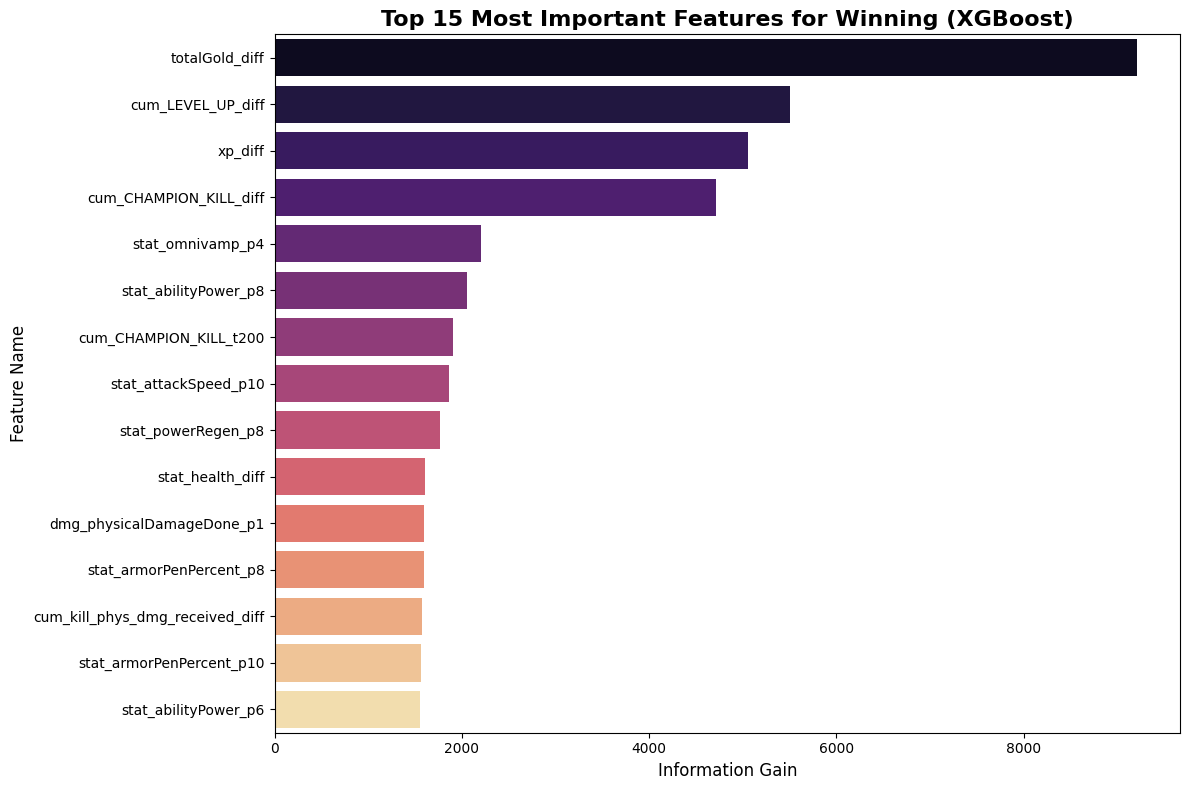

In [18]:
# Visualization

importance_dict = xgb_model.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
})

top_15_xgb = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_xgb, palette='magma')

plt.title('Top 15 Most Important Features for Winning (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Information Gain', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

## With champion data

In [5]:
import gc

CHAMP_FILE = "Data/Champions/champion_mapping.csv"

# Read the champion mapping file
champ_df = pd.read_csv(CHAMP_FILE)

# Split into two teams based on participantId (1-5: t100, 6-10: t200)
t100_champs = champ_df[champ_df['participantId'] <= 5]
t200_champs = champ_df[champ_df['participantId'] > 5]

# One-Hot Encoding for Champions
t100_ohe = pd.get_dummies(t100_champs.set_index('matchId')['championName']).groupby('matchId').max().astype('int8')
t100_ohe.columns = [f"t100_champ_{c}" for c in t100_ohe.columns]

t200_ohe = pd.get_dummies(t200_champs.set_index('matchId')['championName']).groupby('matchId').max().astype('int8')
t200_ohe.columns = [f"t200_champ_{c}" for c in t200_ohe.columns]

# Combine the two teams' champion features into one DataFrame
match_champs = t100_ohe.join(t200_ohe, how='outer').fillna(0).astype('int8')

# Free up memory
del champ_df, t100_champs, t200_champs, t100_ohe, t200_ohe
gc.collect()

print(f"Champion features created: {match_champs.shape[1]} columns for {match_champs.shape[0]} matches.")

Champion features created: 344 columns for 7191 matches.


In [6]:
INPUT_FILE = "master_ml_dataset.csv" 
CHAMP_FILE = "Data/Champions/champion_mapping.csv"

print("Loading champs and One-Hot Encoding...")
champ_df = pd.read_csv(CHAMP_FILE)

# Split into two teams based on participantId (1-5: t100, 6-10: t200)
t100_champs = champ_df[champ_df['participantId'] <= 5]
t200_champs = champ_df[champ_df['participantId'] > 5]

t100_ohe = pd.get_dummies(t100_champs.set_index('matchId')['championName']).groupby('matchId').max().astype('int8')
t100_ohe.columns = [f"t100_champ_{c}" for c in t100_ohe.columns]

t200_ohe = pd.get_dummies(t200_champs.set_index('matchId')['championName']).groupby('matchId').max().astype('int8')
t200_ohe.columns = [f"t200_champ_{c}" for c in t200_ohe.columns]

# Join the two teams and clean up
match_champs = t100_ohe.join(t200_ohe, how='outer').fillna(0).astype('int8')

del champ_df, t100_champs, t200_champs, t100_ohe, t200_ohe
gc.collect()

print(f"[DONE] Created {match_champs.shape[1]} new champion features in the dictionary!")

Loading champs and One-Hot Encoding...
[DONE] Created 344 new champion features in the dictionary!


In [7]:
print("Training and test match IDs loading and splitting...")

# Read only matchId column to get unique match ids
df_matches = pd.read_csv(INPUT_FILE, usecols=['matchId'])
unique_matches = df_matches['matchId'].unique()

train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)
train_matches_set = set(train_matches)
test_matches_set = set(test_matches)

del df_matches
gc.collect()

# Get column names, excluding leakage columns
first_row = pd.read_csv(INPUT_FILE, nrows=1)
leakage_cols = ['timestamp', 'winningTeam', 'type', 'team', 'actor_id'] 
cols_to_use = [c for c in first_row.columns if c not in leakage_cols]

print(f"Training matches: {len(train_matches_set):,} | Test matches: {len(test_matches_set):,}")

Training and test match IDs loading and splitting...
Training matches: 8,178 | Test matches: 2,045


In [8]:
class CSVDataIterator(xgb.DataIter):
    def __init__(self, filename, match_set, chunk_size, match_champs_df, cols, is_test=False):
        self.filename = filename
        self.match_set = match_set
        self.chunk_size = chunk_size
        self.match_champs_df = match_champs_df
        self.cols = cols
        
        self.is_test = is_test
        if self.is_test:
            self.y_true = []
            
        self.iterator = pd.read_csv(self.filename, chunksize=self.chunk_size, usecols=self.cols, low_memory=False)
        super().__init__()

    def reset(self):
        self.iterator = pd.read_csv(self.filename, chunksize=self.chunk_size, usecols=self.cols, low_memory=False)
        if self.is_test:
            self.y_true = []

    def next(self, input_data):
        try:
            chunk = next(self.iterator)
            
            temp_match_id = chunk['matchId'].copy()
            chunk = chunk.drop(columns=['matchId'])
            
            chunk = chunk.apply(pd.to_numeric, errors='coerce')
            
            chunk['matchId'] = temp_match_id 
            chunk.fillna(0, inplace=True)
            
            for col in chunk.columns:
                if chunk[col].dtype == 'float64':
                    chunk[col] = chunk[col].astype('float32')
                elif chunk[col].dtype == 'int64' and col != 'matchId':
                    chunk[col] = chunk[col].astype('int32')
            
            # Add champion features
            chunk = chunk.merge(self.match_champs_df, left_on='matchId', right_index=True, how='left')
            chunk.fillna(0, inplace=True)
            
            # Filter only the matches that are in the current set (train/test)
            filtered_chunk = chunk[chunk['matchId'].isin(self.match_set)].copy()
            
            if filtered_chunk.empty:
                return self.next(input_data)
                
            y = filtered_chunk['target_win_t100'].astype('int8')
            X = filtered_chunk.drop(columns=['matchId', 'target_win_t100'])
            
            # Ensure the same column order for XGBoost
            if not hasattr(self, 'expected_cols'):
                self.expected_cols = list(X.columns)
            else:
                X = X[self.expected_cols] 
            
            if self.is_test:
                self.y_true.extend(y.tolist())
            
            # Pass the data to XGBoost's C++ core
            input_data(data=X, label=y)
            return 1
            
        except StopIteration:
            return 0 # No more data

In [10]:
print("Initializing XGBoost data structures with custom iterator...")

# 150k chunk size
CHUNK_SIZE = 150000

train_iterator = CSVDataIterator(INPUT_FILE, train_matches_set, CHUNK_SIZE, match_champs, cols_to_use)
test_iterator = CSVDataIterator(INPUT_FILE, test_matches_set, CHUNK_SIZE, match_champs, cols_to_use, is_test=True)

# Iterator for QuantileDMatrix
dtrain = xgb.QuantileDMatrix(train_iterator)

# Reference is required for the test iterator to ensure consistent feature mapping
dtest = xgb.QuantileDMatrix(test_iterator, ref=dtrain)

print("\n[SUCCESS] XGBoost structures successfully initialized!")

Initializing XGBoost data structures with custom iterator...

[SUCCESS] XGBoost structures successfully initialized!


In [14]:
print("Initializing XGBoost model training...")

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,                 
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'max_bin': 256,                    
    'n_jobs': -1,                     
    'random_state': 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,             
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=20
)

print("\n[SUCCESS] XGBoost Model trained!")

Initializing XGBoost model training...


NameError: name 'dtrain' is not defined

In [12]:
# Evaluation
print("\nEvaluation...")
y_prob_xgb = xgb_model.predict(dtest)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

y_test_labels = dtest.get_label()

accuracy_xgb = accuracy_score(y_test_labels, y_pred_xgb)
roc_auc_xgb = auc(*roc_curve(y_test_labels, y_prob_xgb)[:2])

print("\nXGBoost Model Performance:")
print(f"ACCURACY: {accuracy_xgb * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}\n")

# Feature importance
print("Most important features according to XGBoost:")
importance_dict = xgb_model.get_score(importance_type='gain')
importance_df = pd.DataFrame({'Feature': list(importance_dict.keys()), 'Importance': list(importance_dict.values())})

top_features = importance_df.sort_values(by='Importance', ascending=False).head(15)
champ_importance = importance_df[importance_df['Feature'].str.contains('champ_')].sort_values(by='Importance', ascending=False)

print("\nTOP 15 Most Important Features:")
print(top_features.to_string(index=False))

print("\nTOP 10 Most Influential Champions according to the model:")
if not champ_importance.empty:
    print(champ_importance.head(10).to_string(index=False))
else:
    print("Champs not found in feature importance.")


Evaluation...

XGBoost Model Performance:
ACCURACY: 71.45%
ROC-AUC Score: 0.8001

Most important features according to XGBoost:

TOP 15 Most Important Features:
               Feature   Importance
        totalGold_diff 23827.130859
     cum_LEVEL_UP_diff  7499.520996
               xp_diff  6981.024902
cum_CHAMPION_KILL_diff  6571.070312
     t100_champ_Maokai  3655.322266
      t100_champ_Corki  3417.862061
     t100_champ_Twitch  3132.187500
     t100_champ_Yunara  3080.653320
        t200_champ_Zed  3062.458740
      t200_champ_Nasus  3012.827881
         t200_champ_Vi  2954.127930
      t100_champ_Briar  2921.588867
     t100_champ_Velkoz  2836.625244
t100_champ_MissFortune  2808.544189
    t200_champ_XinZhao  2785.086670

TOP 10 Most Influential Champions according to the model:
               Feature  Importance
     t100_champ_Maokai 3655.322266
      t100_champ_Corki 3417.862061
     t100_champ_Twitch 3132.187500
     t100_champ_Yunara 3080.653320
        t200_champ_Zed 3062.

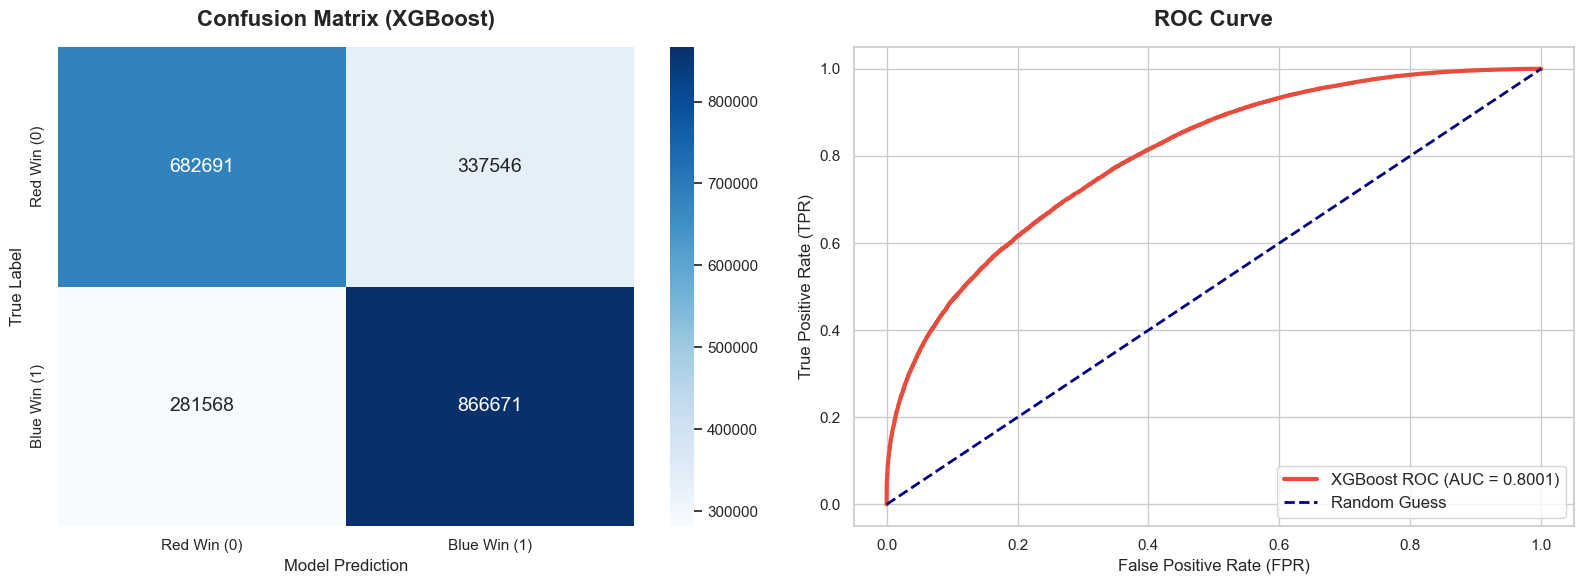

In [13]:
# Ábrák és stílus beállítása
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix (XGBoost)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Model Prediction', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xticklabels(['Red Win (0)', 'Blue Win (1)'])
axes[0].set_yticklabels(['Red Win (0)', 'Blue Win (1)'])

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_labels, y_prob_xgb)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=3, label=f'XGBoost ROC (AUC = {roc_auc_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[1].set_title('ROC Curve', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\bognarb\AppData\Local\Temp\ipykernel_32640\3192189130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=axes[0])
C:\Users\bognarb\AppData\Local\Temp\ipykernel_32640\3192189130.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_champs, palette='magma', ax=axes[1])


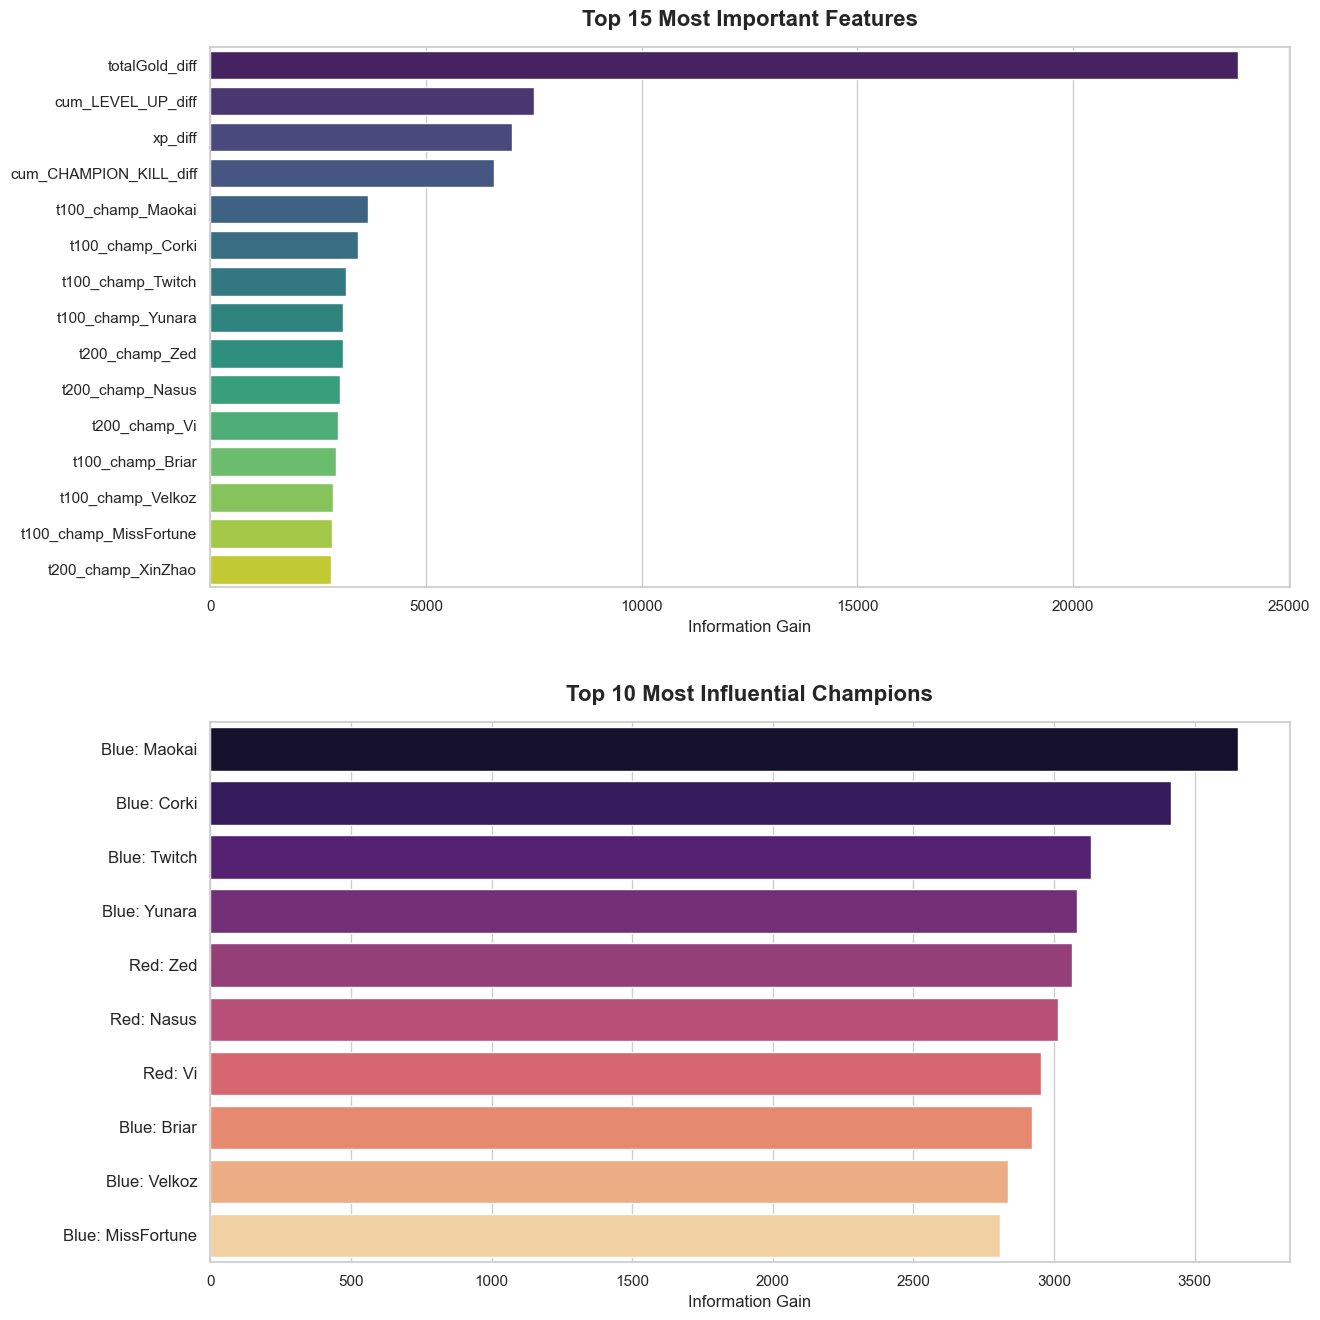

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# TOP 15 most important features
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=axes[0])
axes[0].set_title('Top 15 Most Important Features', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Information Gain', fontsize=12)
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', labelsize=11)

# TOP 10 most influential champions
if not champ_importance.empty:
    plot_champs = champ_importance.head(10).copy()
    plot_champs['Feature'] = plot_champs['Feature'].str.replace('t100_champ_', 'Blue: ')
    plot_champs['Feature'] = plot_champs['Feature'].str.replace('t200_champ_', 'Red: ')
    
    sns.barplot(x='Importance', y='Feature', data=plot_champs, palette='magma', ax=axes[1])
    axes[1].set_title('Top 10 Most Influential Champions', fontsize=16, fontweight='bold', pad=15)
    axes[1].set_xlabel('Information Gain', fontsize=12)
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='y', labelsize=12)
else:
    axes[1].text(0.5, 0.5, 'The model did not find any exceptionally important champions.', 
                 ha='center', va='center', fontsize=14, color='gray')
    axes[1].set_axis_off()

plt.tight_layout(pad=3.0)
plt.show()

In [15]:
import itertools

# Grid search parameters
param_grid = {
    'max_depth': [5, 7, 9],           
    'learning_rate': [0.05, 0.1, 0.2] 
}

# Base parameters that remain constant across all models
base_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'max_bin': 256,                   
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_jobs': -1,
    'random_state': 42
}

# All combinations of the parameters to test
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Over {len(combinations)} different models we will train.")

# Variables to store the best results
best_auc = 0
best_params = None
best_n_estimators = 0

evals = [(dtrain, 'train'), (dtest, 'test')]

# Grid search loop
for i, combo in enumerate(combinations, 1):
    print(f"--- Test {i}/{len(combinations)} ---")
    print(f"Tested parameters: {combo}")
    
    current_params = base_params.copy()
    current_params.update(combo)
    
    # Train the model with early stopping to find the optimal number of trees (n_estimators)
    model = xgb.train(
        params=current_params, 
        dtrain=dtrain, 
        num_boost_round=1000,         # Maximum 1000 trees
        evals=evals, 
        early_stopping_rounds=30,     # Maximum 30 rounds without improvement on the test set
        verbose_eval=False
    )
    
    # Save the best score and the corresponding n_estimators
    current_best_score = model.best_score
    current_best_iteration = model.best_iteration
    
    print(f"Result AUC: {current_best_score:.4f} (Optimal n_estimators: {current_best_iteration})\n")
    
    # Save the best results if this model is better than the previous best
    if current_best_score > best_auc:
        best_auc = current_best_score
        best_params = combo
        best_n_estimators = current_best_iteration

# Evaluate and print the best results
print("GRID SEARCH RESULTS")
print(f"BEST AUC SCORE: {best_auc:.4f}")
print("BEST PARAMETERS:")
print(f"max_depth: {best_params['max_depth']}")
print(f"learning_rate: {best_params['learning_rate']}")
print(f"n_estimators (Optimal number of trees): {best_n_estimators}")

Over 9 different models we will train.
--- Test 1/9 ---
Tested parameters: {'max_depth': 5, 'learning_rate': 0.05}
Result AUC: 0.8047 (Optimal n_estimators: 88)

--- Test 2/9 ---
Tested parameters: {'max_depth': 5, 'learning_rate': 0.1}
Result AUC: 0.8032 (Optimal n_estimators: 37)

--- Test 3/9 ---
Tested parameters: {'max_depth': 5, 'learning_rate': 0.2}
Result AUC: 0.8035 (Optimal n_estimators: 22)

--- Test 4/9 ---
Tested parameters: {'max_depth': 7, 'learning_rate': 0.05}
Result AUC: 0.8034 (Optimal n_estimators: 73)

--- Test 5/9 ---
Tested parameters: {'max_depth': 7, 'learning_rate': 0.1}
Result AUC: 0.8030 (Optimal n_estimators: 39)

--- Test 6/9 ---
Tested parameters: {'max_depth': 7, 'learning_rate': 0.2}
Result AUC: 0.8018 (Optimal n_estimators: 12)

--- Test 7/9 ---
Tested parameters: {'max_depth': 9, 'learning_rate': 0.05}
Result AUC: 0.8031 (Optimal n_estimators: 84)

--- Test 8/9 ---
Tested parameters: {'max_depth': 9, 'learning_rate': 0.1}
Result AUC: 0.8028 (Optimal n

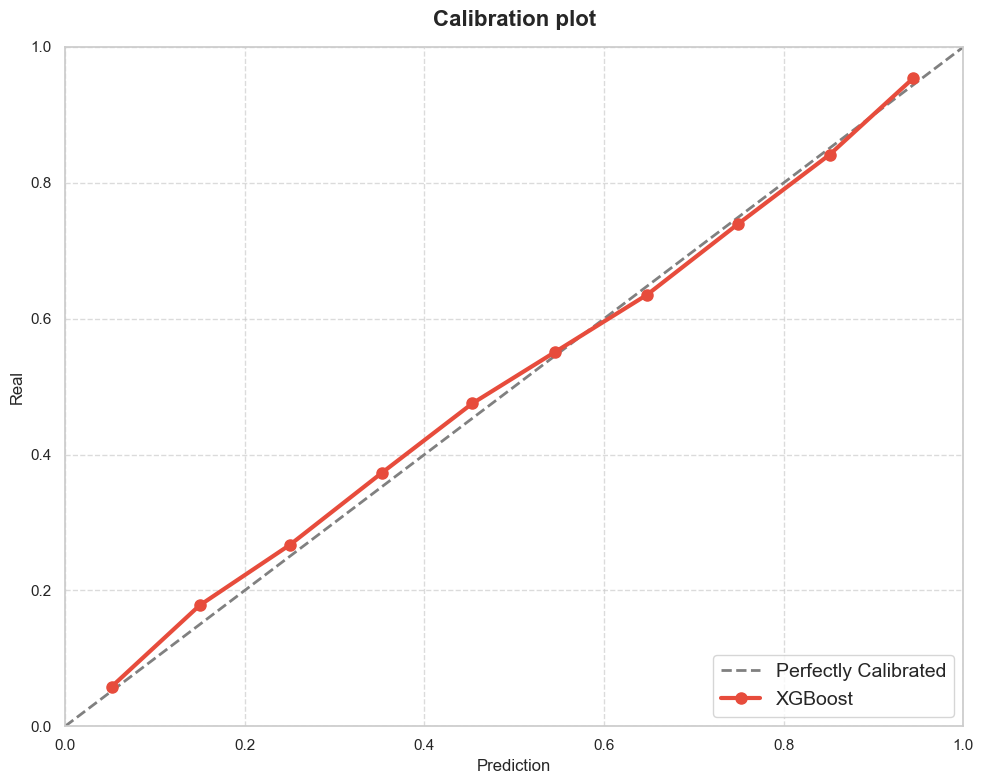

In [17]:
from sklearn.calibration import calibration_curve

# Calculation
prob_true, prob_pred = calibration_curve(y_test_labels, y_prob_xgb, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Perfect calibration
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, label='Perfectly Calibrated')

# XGBoost
plt.plot(prob_pred, prob_true, marker='o', markersize=8, color='#e74c3c', linewidth=3, label='XGBoost')

plt.title('Calibration plot', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.legend(loc='lower right', fontsize=14)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## LSTM

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Read
N_ROWS = 2000000 

df_lstm_raw = pd.read_csv(INPUT_FILE, nrows=N_ROWS, usecols=cols_to_use + ['matchId'])

# Shrinking
temp_match_id = df_lstm_raw['matchId'].copy()
df_lstm_raw = df_lstm_raw.apply(pd.to_numeric, errors='coerce')
df_lstm_raw['matchId'] = temp_match_id
df_lstm_raw.fillna(0, inplace=True)

# Merge
df_lstm = df_lstm_raw.merge(match_champs, left_on='matchId', right_index=True, how='left')
df_lstm.fillna(0, inplace=True)

del df_lstm_raw
gc.collect()

MAX_MINUTES = 35 # 35 minutes max

X_list = []
y_list = []

# Group
for match_id, group in df_lstm.groupby('matchId'):
    # Y
    y = group['target_win_t100'].iloc[-1]
    
    # Features
    features = group.drop(columns=['matchId', 'target_win_t100']).values
    
    X_list.append(features)
    y_list.append(y)

# Padding
X_lstm = pad_sequences(X_list, maxlen=MAX_MINUTES, padding='post', dtype='float32')
y_lstm = np.array(y_list)

print(f"X shape: {X_lstm.shape}")
print(f"Y shape: {y_lstm.shape}")

# Train-test split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

C:\Users\Balázs\AppData\Local\Temp\ipykernel_2736\2218845330.py:7: DtypeWarning: Columns (0: creatorId, 1: wardType, 2: killerId, 3: laneType, 4: positionY, 5: killStreakLength, 6: multiKillLength, 7: goldGain, 8: killerTeamId, 9: monsterSubType, 10: buildingType, 11: towerType, 12: actualStartTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lstm_raw = pd.read_csv(INPUT_FILE, nrows=N_ROWS, usecols=cols_to_use + ['matchId'])


X shape: (1857, 35, 1041)
Y shape: (1857,)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

n_timesteps = X_lstm.shape[1] 
n_features = X_lstm.shape[2]  

lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    
    # 1st LSTM layer
    LSTM(64, return_sequences=True),
    Dropout(0.3),                 
    BatchNormalization(),         
    
    # 2nd LSTM layer
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

lstm_model.summary()

# Training
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=15, 
    batch_size=32, 
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

print("\n[SUCCESS] LSTM model trained!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 35, 64)         │       283,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,481 (1.13 MB)

 Trainable params: 296,289 (1.13 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5542 - auc: 0.5885 - loss: 0.7399 - val_accuracy: 0.5430 - val_auc: 0.6390 - val_loss: 0.6883
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5643 - auc: 0.5856 - loss: 0.7098 - val_accuracy: 0.5349 - val_auc: 0.5768 - val_loss: 0.6781
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5744 - auc: 0.6167 - loss: 0.6798 - val_accuracy: 0.5726 - val_auc: 0.6334 - val_loss: 0.6692
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6007 - auc: 0.6437 - loss: 0.6605 - val_accuracy: 0.6237 - val_auc: 0.6955 - val_loss: 0.6483
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6007 - auc: 0.6547 - loss: 0.6515 - val_accuracy: 0.6075 - val_auc: 0.6576 - val_loss: 0.6535
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6263 - auc: 0.6656 - loss: 0.6513 - val_accuracy: 0.6290 - val_auc: 0.7062 - val_loss: 0.6289
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms

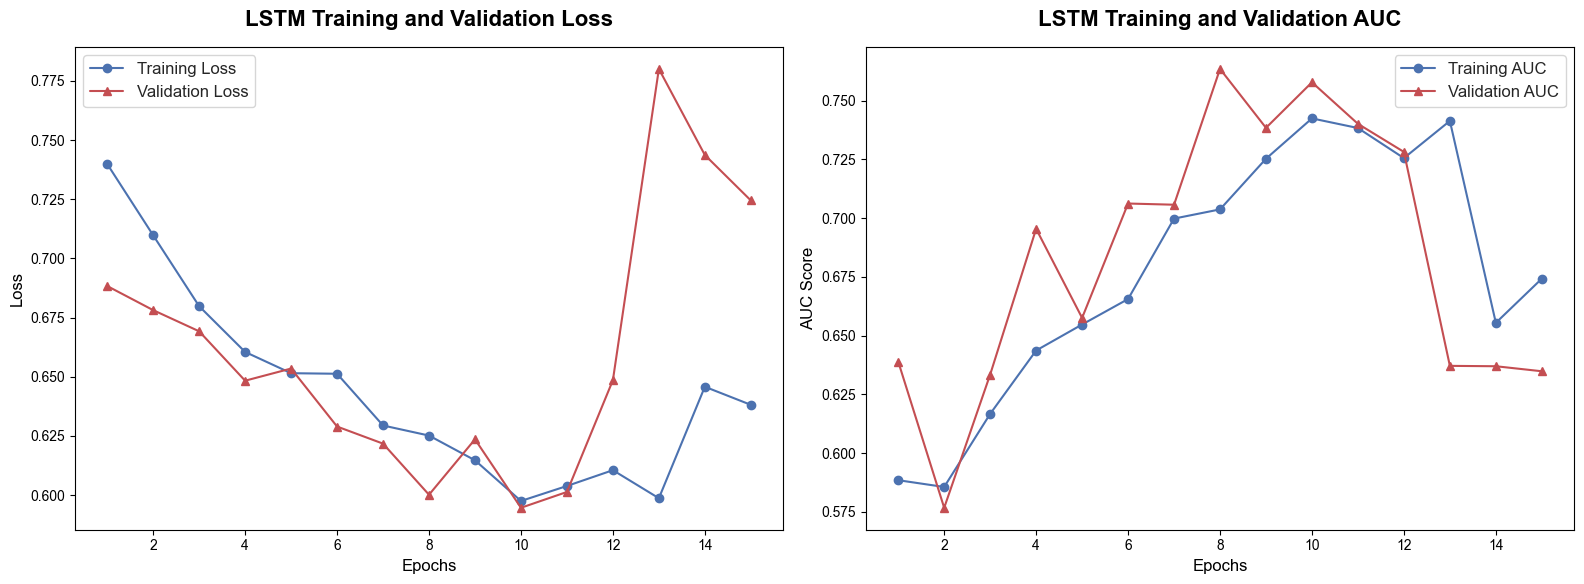

In [11]:
# Extracting data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
auc = history.history['auc']
val_auc = history.history['val_auc']

epochs = range(1, len(acc) + 1)

# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Loss curve  
axes[0].plot(epochs, loss, 'bo-', label='Training Loss')
axes[0].plot(epochs, val_loss, 'r^-', label='Validation Loss')
axes[0].set_title('LSTM Training and Validation Loss', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=12)

# AUC curve
axes[1].plot(epochs, auc, 'bo-', label='Training AUC')
axes[1].plot(epochs, val_auc, 'r^-', label='Validation AUC')
axes[1].set_title('LSTM Training and Validation AUC', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('AUC Score', fontsize=12)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

================ FINAL RESULTS ================
  Model  Accuracy  AUC Score
XGBoost   0.75000   0.820000
   LSTM   0.58871   0.633198



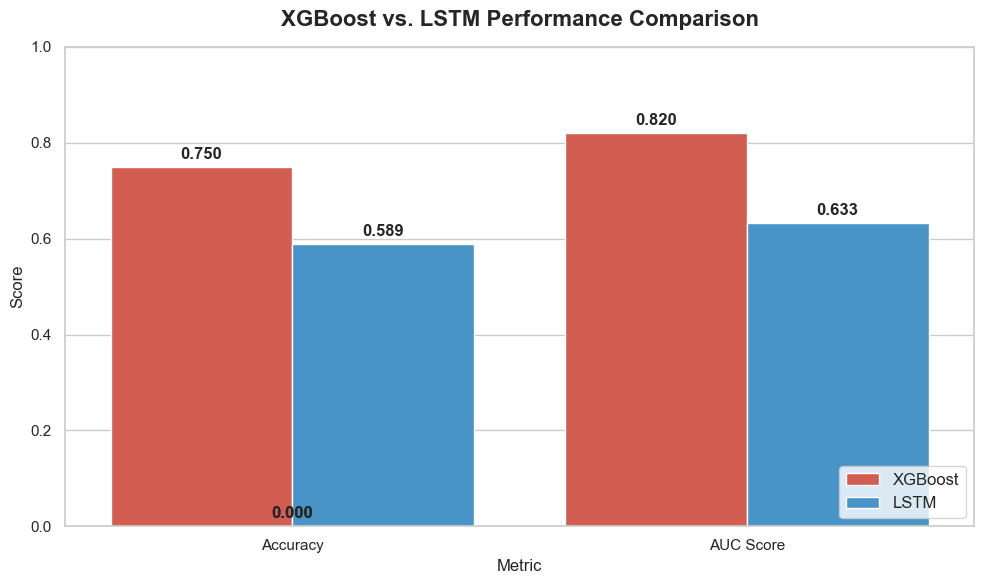

In [13]:
from sklearn.metrics import roc_auc_score

# LSTM predictions
y_prob_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

xgb_acc = 0.75  
xgb_auc = 0.82

lstm_acc = accuracy_score(y_test_lstm, y_pred_lstm)
lstm_auc = roc_auc_score(y_test_lstm, y_prob_lstm)

# Table of results
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'LSTM'],
    'Accuracy': [xgb_acc, lstm_acc],
    'AUC Score': [xgb_auc, lstm_auc]
})

print("\n================ FINAL RESULTS ================")
print(results_df.to_string(index=False))
print("===============================================\n")

# Charting the results
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette=['#e74c3c', '#3498db'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('XGBoost vs. LSTM Performance Comparison', fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 1.0)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\bognarb\AppData\Local\Temp\ipykernel_4300\3920358969.py:2: DtypeWarning: Columns (0: monsterType, 1: monsterSubType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_match = pd.read_csv('event_driven_1match_sample.csv')
C:\Users\bognarb\AppData\Local\Temp\ipykernel_4300\3920358969.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  minute_snapshots = df_match.groupby('minute').last().reset_index()


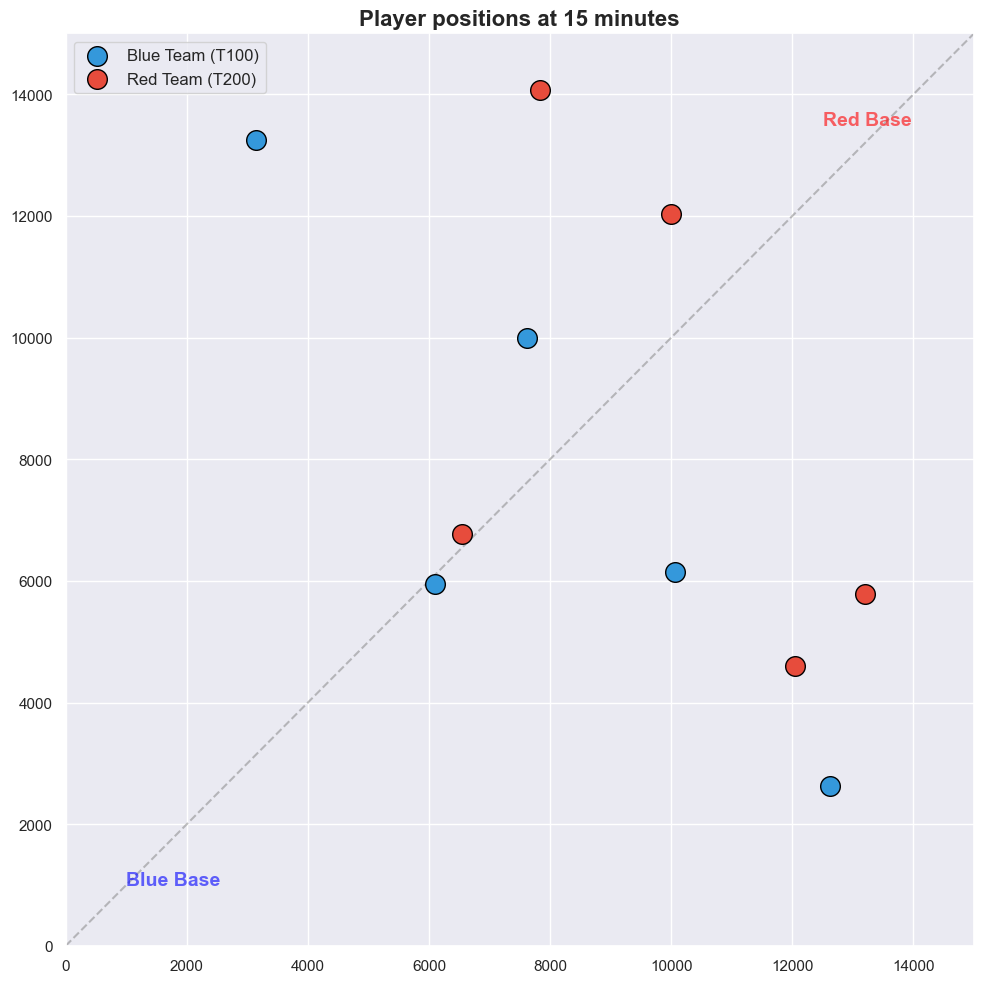

In [24]:
# 1 match
df_match = pd.read_csv('event_driven_1match_sample.csv')

# Minutes
minute_snapshots = df_match.groupby('minute').last().reset_index()

TARGET_MINUTE = 15
snapshot_15 = minute_snapshots[minute_snapshots['minute'] == TARGET_MINUTE].iloc[0]

blue_x = [snapshot_15[f'positionX_p{i}'] for i in range(1, 6)]
blue_y = [snapshot_15[f'positionY_p{i}'] for i in range(1, 6)]

red_x = [snapshot_15[f'positionX_p{i}'] for i in range(6, 11)]
red_y = [snapshot_15[f'positionY_p{i}'] for i in range(6, 11)]

plt.figure(figsize=(10, 10))
sns.set_theme(style="darkgrid")

# Scatter plot
plt.scatter(blue_x, blue_y, c='#3498db', s=200, edgecolors='black', label='Blue Team (T100)', zorder=5)
plt.scatter(red_x, red_y, c='#e74c3c', s=200, edgecolors='black', label='Red Team (T200)', zorder=5)

# Borders
plt.xlim(0, 15000)
plt.ylim(0, 15000)
plt.title(f'Player positions at {TARGET_MINUTE} minutes', fontsize=16, fontweight='bold')
plt.legend(loc='upper left', fontsize=12)

plt.plot([0, 15000], [0, 15000], linestyle='--', color='gray', alpha=0.5)
plt.text(1000, 1000, 'Blue Base', fontsize=14, color='blue', alpha=0.6, fontweight='bold')
plt.text(12500, 13500, 'Red Base', fontsize=14, color='red', alpha=0.6, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# XGBoost Lite
df_fast = pd.read_csv(INPUT_FILE, nrows=500000, usecols=cols_to_use + ['matchId'])

temp_match_id = df_fast['matchId'].copy()
df_fast = df_fast.drop(columns=['matchId']).apply(pd.to_numeric, errors='coerce', downcast='float')
df_fast['matchId'] = temp_match_id
df_fast.fillna(0, inplace=True)

df_fast = df_fast.merge(match_champs, left_on='matchId', right_index=True, how='left')
df_fast.fillna(0, inplace=True)

y = df_fast['target_win_t100'].astype('int8')
X = df_fast.drop(columns=['matchId', 'target_win_t100'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

del df_fast
gc.collect()


dtrain_fast = xgb.DMatrix(X_train, label=y_train)
dtest_fast = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,                 
    'learning_rate': 0.1,
    'tree_method': 'hist',
    'max_bin': 256,                    
    'n_jobs': -1,                     
    'random_state': 42
}

evals = [(dtrain_fast, 'train'), (dtest_fast, 'test')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain_fast,
    num_boost_round=1000,             
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=50
)

print("\n[SUCCESS] XGBoost model trained!")

C:\Users\bognarb\AppData\Local\Temp\ipykernel_4300\1516267254.py:2: DtypeWarning: Columns (0: name, 1: actualStartTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fast = pd.read_csv(INPUT_FILE, nrows=500000, usecols=cols_to_use + ['matchId'])


[0]	train-auc:0.88458	test-auc:0.88538
[50]	train-auc:0.99898	test-auc:0.99897
[100]	train-auc:0.99999	test-auc:0.99999
[150]	train-auc:1.00000	test-auc:1.00000
[200]	train-auc:1.00000	test-auc:1.00000
[204]	train-auc:1.00000	test-auc:1.00000

[SUCCESS] XGBoost Modell betanítva!


Found matches: ['KR_8031700522', 'KR_8031786686', 'KR_8033124346', 'KR_8035806533', 'KR_8036705617']


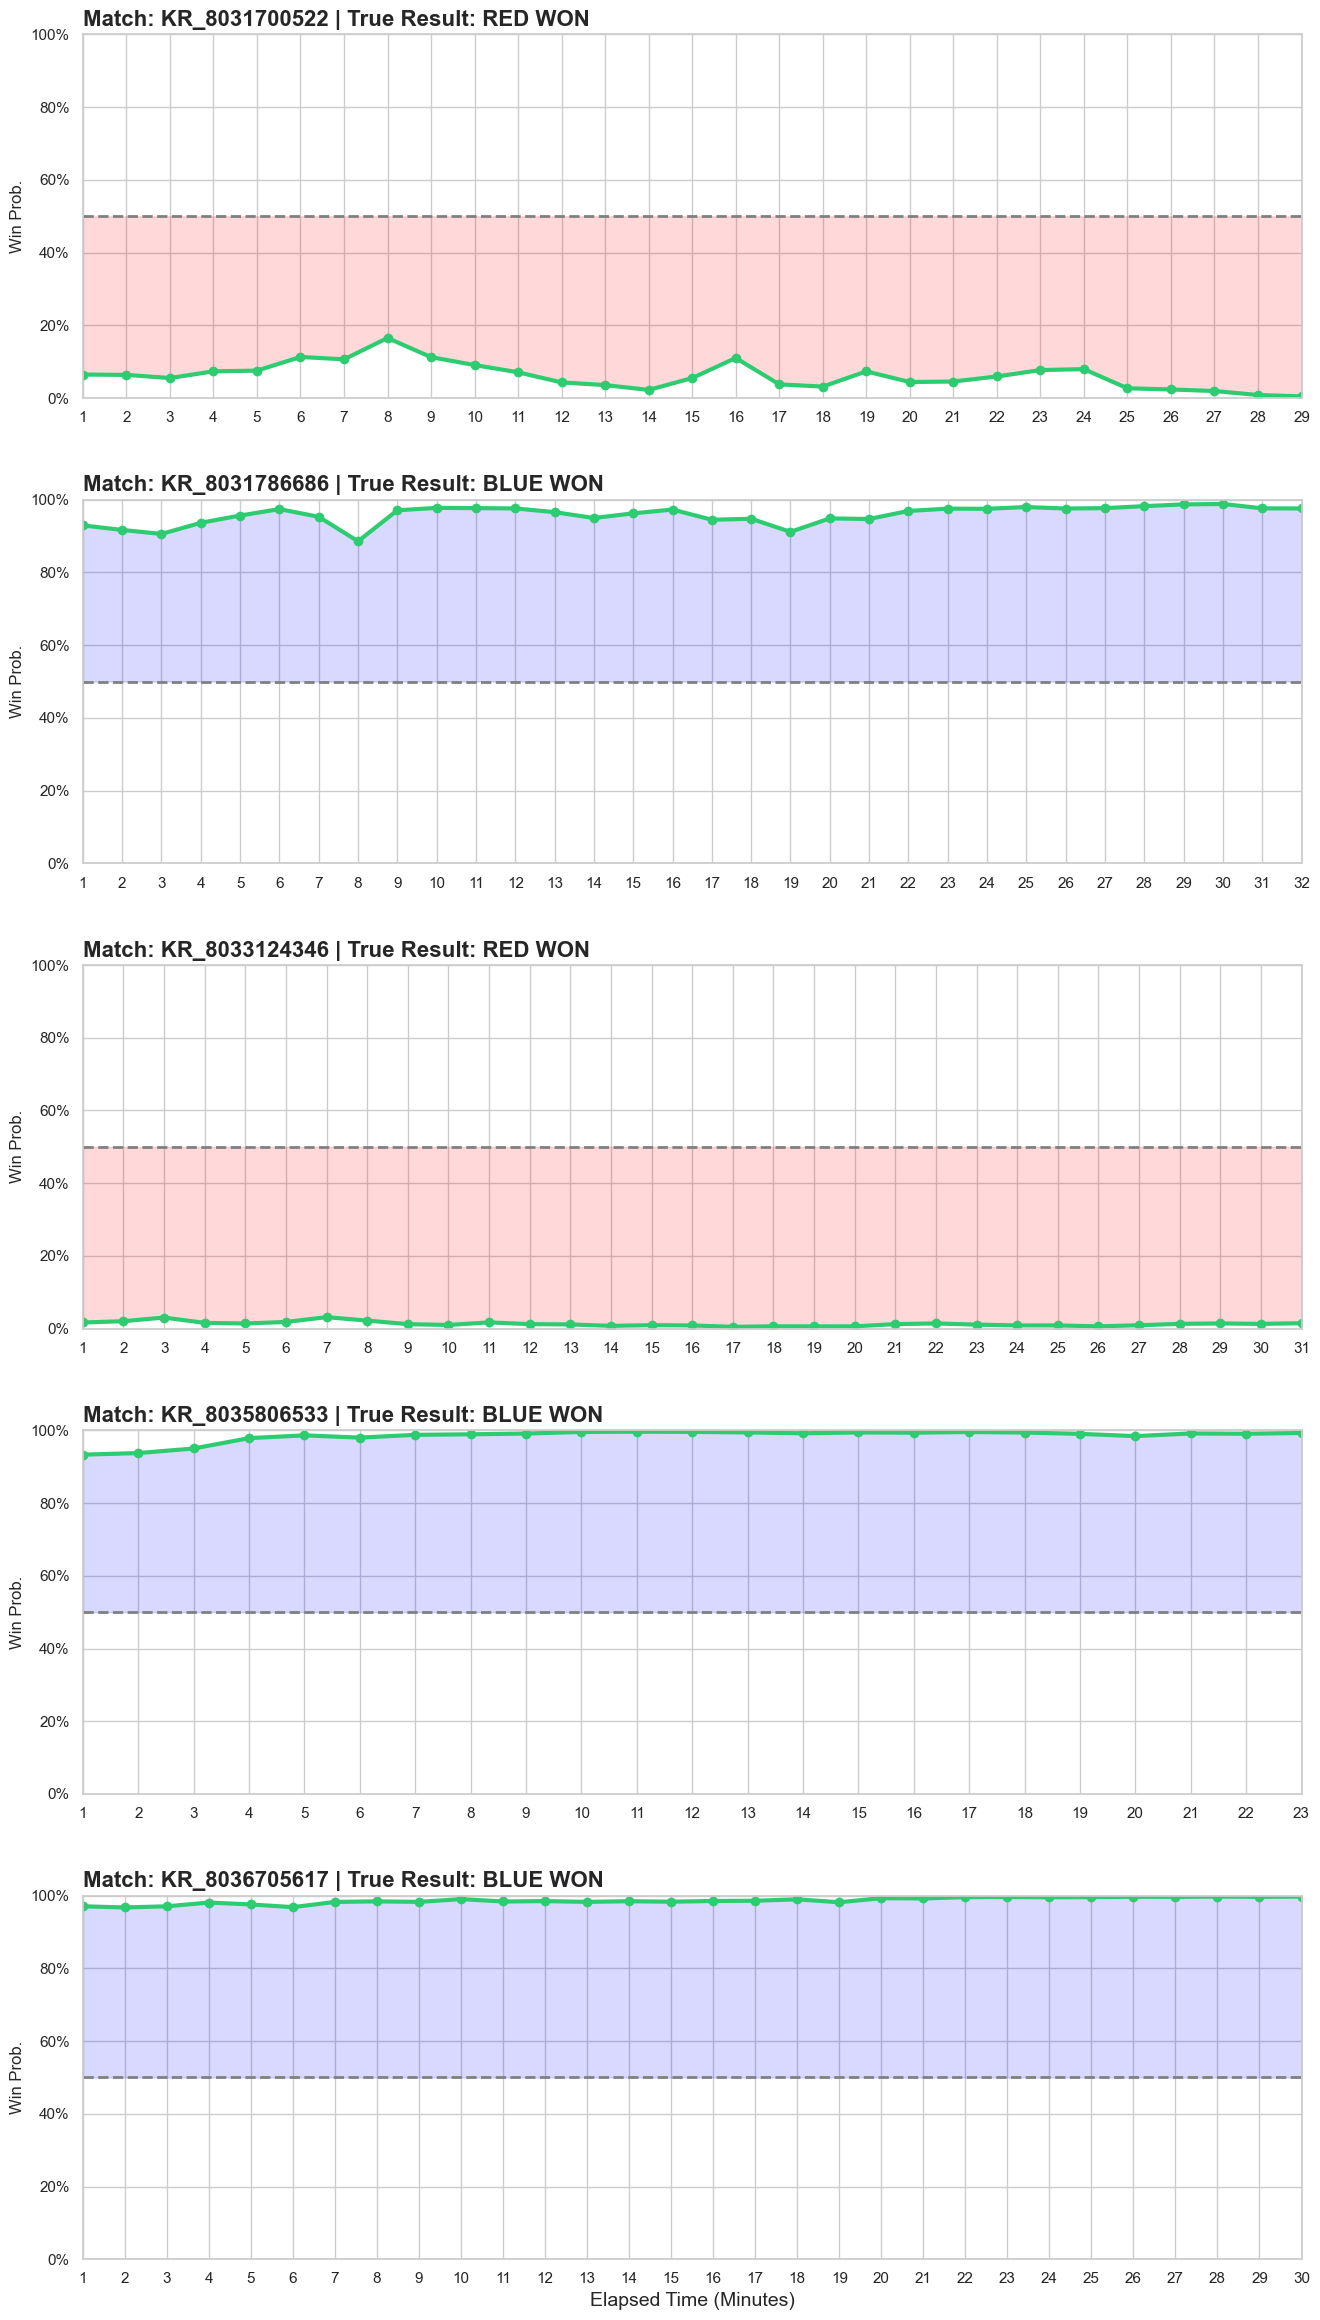

In [23]:
# Read a small chunk (100k rows is enough for 5 matches)
df_chunk = pd.read_csv(INPUT_FILE, nrows=100000, usecols=cols_to_use + ['matchId', 'target_win_t100'])

# Get the first 5 unique match IDs
unique_matches = df_chunk['matchId'].unique()[:5]
print(f"Found matches: {list(unique_matches)}")

# Keep only these 5 matches
df_5matches = df_chunk[df_chunk['matchId'].isin(unique_matches)].copy()

del df_chunk
gc.collect()

# Group by match and minute, keeping the last event of each minute
minute_snapshots = df_5matches.groupby(['matchId', 'minute']).last().reset_index()

# Preparations
df_pred_raw = minute_snapshots.copy()
temp_match_id = df_pred_raw['matchId'].copy()

# Force numeric format and temporarily drop the text ID
df_pred_raw = df_pred_raw.drop(columns=['matchId']).apply(pd.to_numeric, errors='coerce', downcast='float')
df_pred_raw['matchId'] = temp_match_id
df_pred_raw.fillna(0, inplace=True)

# Merge champion data from the memory dictionary
df_pred = df_pred_raw.merge(match_champs, left_on='matchId', right_index=True, how='left')
df_pred.fillna(0, inplace=True)

# Reindex
expected_cols = xgb_model.feature_names
X_5matches = df_pred.reindex(columns=expected_cols, fill_value=0)
X_5matches = X_5matches.apply(pd.to_numeric, errors='coerce').fillna(0)

# Run predictions for all minutes of all 5 matches at once
d_5matches = xgb.DMatrix(X_5matches)
win_probabilities = xgb_model.predict(d_5matches)

# Write predictions back to the dataframe to associate them with the right matches
minute_snapshots['win_prob'] = win_probabilities


fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 24), sharex=False)
sns.set_theme(style="whitegrid")

for i, match_id in enumerate(unique_matches):
    ax = axes[i]
    
    # Filter data for the current match
    match_data = minute_snapshots[minute_snapshots['matchId'] == match_id]
    minutes = match_data['minute'].values
    probs = match_data['win_prob'].values
    true_winner = match_data['target_win_t100'].iloc[-1]
    
    # Draw prediction line and 50% baseline
    ax.plot(minutes, probs, color='#2ecc71', linewidth=3, marker='o', markersize=6, label='Blue (T100) Win Probability')
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
    
    # Fill areas under and above 50% to show dominance
    ax.fill_between(minutes, probs, 0.5, where=(probs >= 0.5), interpolate=True, color='blue', alpha=0.15)
    ax.fill_between(minutes, probs, 0.5, where=(probs < 0.5), interpolate=True, color='red', alpha=0.15)
    
    # Labels and styling
    winner_text = "BLUE WON" if true_winner == 1 else "RED WON"
    ax.set_title(f'Match: {match_id} | True Result: {winner_text}', fontsize=16, fontweight='bold', loc='left')
    
    ax.set_ylim(0, 1)
    ax.set_xlim(1, minutes.max())
    ax.set_xticks(minutes)
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel('Win Prob.', fontsize=12)
    
    if i == 4:
        ax.set_xlabel('Elapsed Time (Minutes)', fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()